In [1]:
import pandas as pd
df = pd.read_csv('./binary_tools/atomic_lines.csv',delimiter='\t')
df.columns

Index(['element', 'wave_A', 'loggf', 'lower_state_eV', 'lower_j',
       'upper_state_eV', 'upper_j', 'upper_g', 'stark', 'theoretical_depth',
       'theoretical_ew', 'upper_orbital_type', 'molecule', 'ion',
       'reference_code'],
      dtype='object')

In [1]:
from binary_tools.gfp import GFP
import binary_tools

2026-04-18 23:10:23.114117: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-18 23:10:23.117312: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-18 23:10:23.158209: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-18 23:10:23.158255: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-18 23:10:23.158280: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

[LogicalDevice(name='/device:CPU:0', device_type='CPU')]


2026-04-18 23:10:25.294402: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


# Generate Spectrum

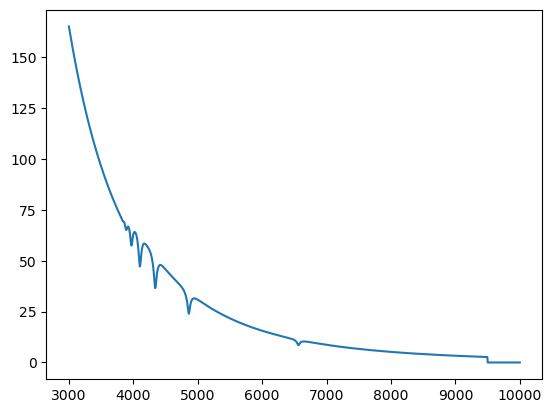

In [2]:
from binary_tools.gfp import GFP,logteff_logg_to_mass
import numpy as np
from matplotlib import pyplot as plt
import astropy.units as u
import astropy.constants as c
wl = np.linspace(3000,10000,1000) #Ang
resolution = (wl.max()-wl.min())/len(wl)
specclass='DA'
logteff_logg_to_mass_DA = logteff_logg_to_mass(specclass)
gfp = GFP(resolution = resolution, specclass = specclass)
gfp.parallax=(1e3/2.711*u.pc).to(u.cm).value

Teff =33079 #K
logg=8.27 
rv = 19 #km/s
mass = logteff_logg_to_mass_DA(np.log10(Teff),logg)
radius = np.sqrt(mass*u.M_sun*c.G / (10**(logg)*u.cm/u.s**2)).to(u.R_sun).value

fl = gfp.spectrum_sampler(wl,np.array([[Teff,logg,radius,rv]]),specclass=specclass)
plt.plot(wl,fl)


# Spectrum Fitting

/tmp/ipykernel_15179/3174153846.py:21: DeprecationWarning: Please import `Delaunay` from the `scipy.spatial` namespace; the `scipy.spatial.qhull` namespace is deprecated and will be removed in SciPy 2.0.0.
  logteff_logg_to_mass_MS = pickle.load(file)


now trying:  MS
init_paras [[7696.39493048602, 4.444012089898343, -1.0366046733647412, 0, 0], [6.705119840794476, 0.0015069914145319, 0.0185758999698158, 0, 0]]
drop 0
fitting continuum...
test bin...
init_para: [[7696.39493048602, 4.444012089898343, -1.0366046733647412, 0, 0], [6.705119840794476, 0.0015069914145319, 0.0185758999698158, 0, 0]]
init_chi: 3406.8048620529685
final optimization...
done fitting
res of lmfit: teff1 logg1 meta1 rv1
mle: [7696.39493048602, 4.444012089898343, -1.0366046733647412, -189.903320542633]
stds: [6.705119840794476, 0.0015069914145319, 0.0185758999698158, 60]
redchi: 0.9089660784559681 chimin: 3406.8048620529685
burning in chains...


100%|██████████| 300/300 [02:46<00:00,  1.80it/s]


sampling posterior...


100%|██████████| 200/200 [01:54<00:00,  1.75it/s]


acceptance fraction:    0.510
mass length: 1
make plot
Final parameters: [array([ 7.64660270e+03,  4.44106404e+00, -8.89927648e-01, -1.89977363e+02])] ['MS'] [1.1136653045695901]
[array([ 7.64660270e+03,  4.44106404e+00, -8.89927648e-01, -1.89977363e+02])] [array([4.20665223e+00, 1.70636463e-03, 2.30091875e-02, 2.66453729e+00])]


,teff1,logg1,meta1,rv1,mass,radius
0,7646.602703,4.441064,-0.889928,-189.977363,1.248490,1.113665
1,4.206652,0.001706,0.023009,2.664537,0.005609,0.003323
2,4.260872,0.001688,0.023865,2.533678,0.002076,0.001388
3,4.221831,0.001896,0.022952,2.549232,0.003396,0.001421


0.6705413965891918


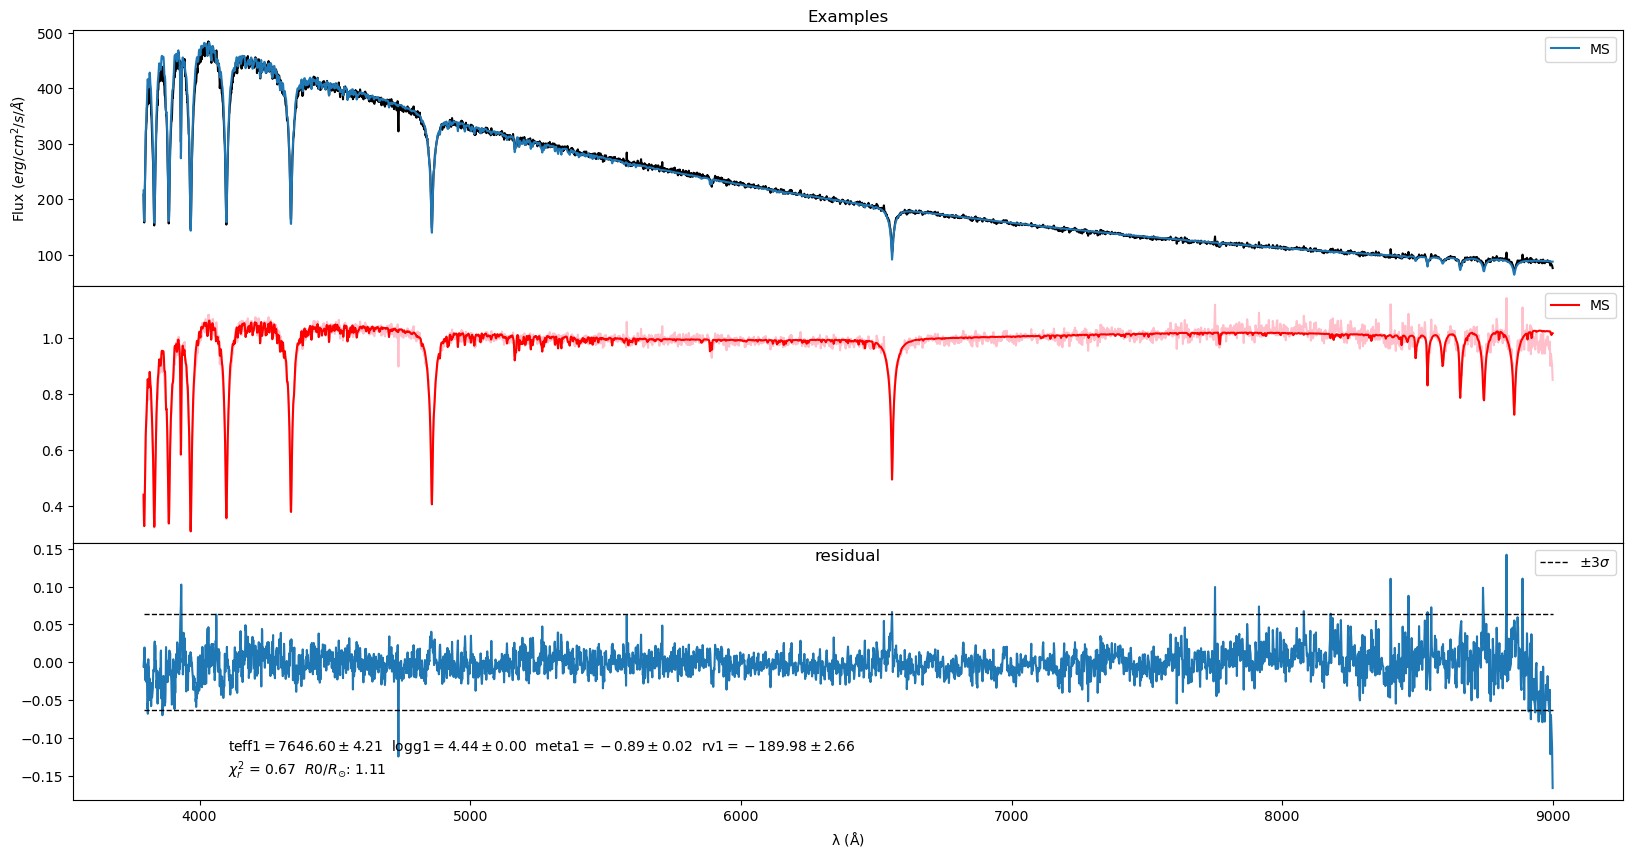

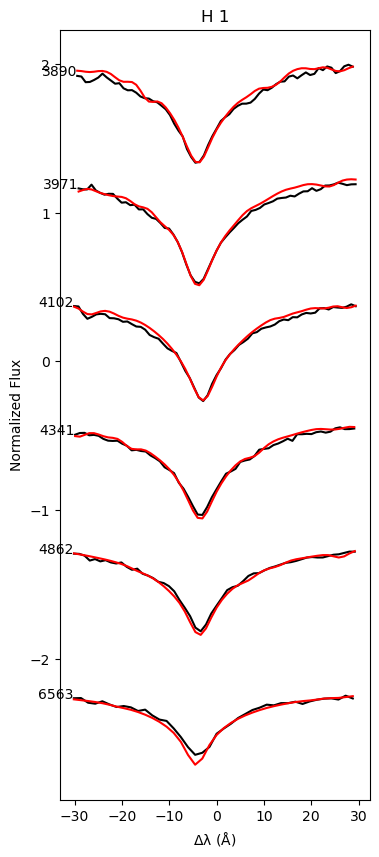

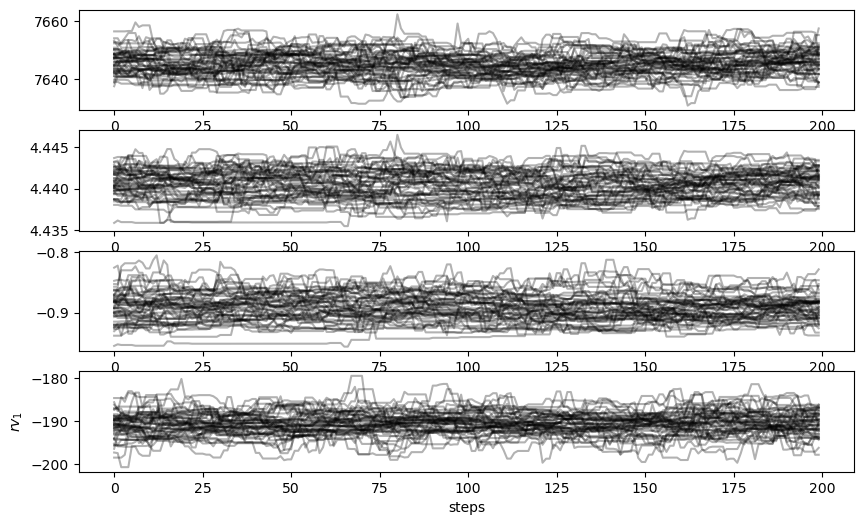

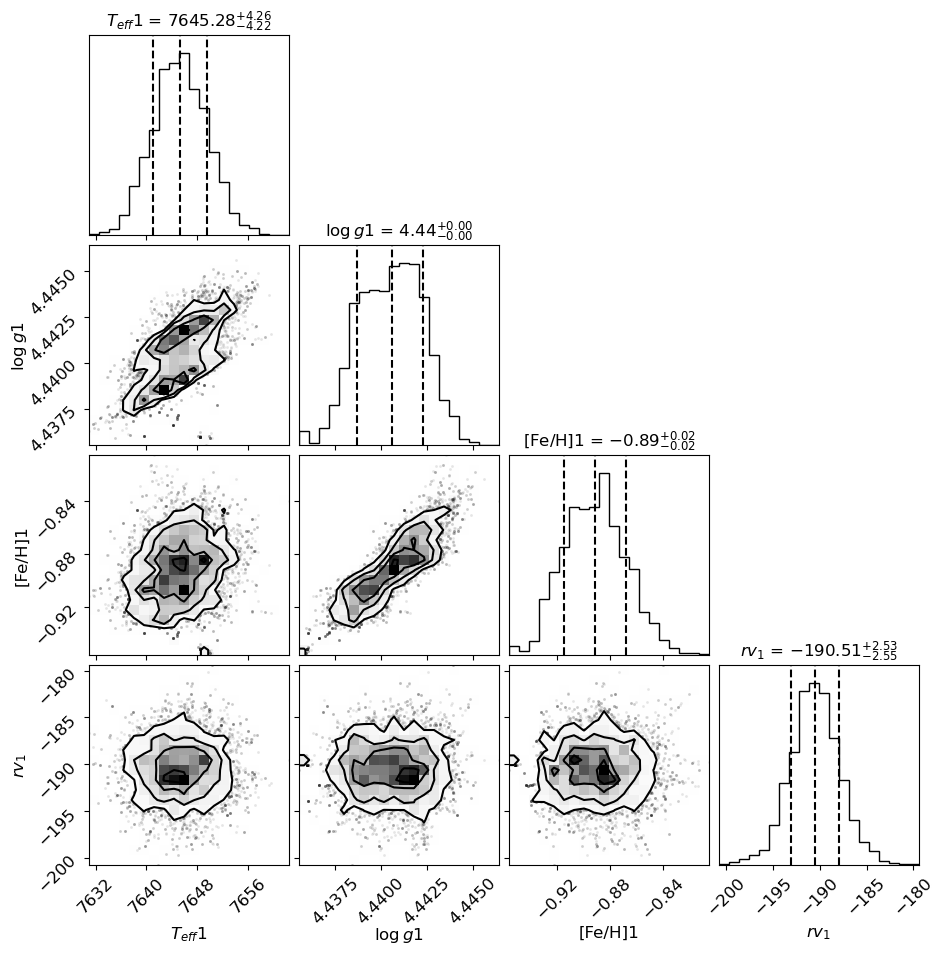

In [ ]:
import binary_tools
from binary_tools.gfp import GFP
import numpy as np
import pandas as pd
from astropy.io import fits
from matplotlib import pyplot as plt
import astropy.units as u
import pickle
data = pd.read_csv('./spec-1677-53148-0521.txt',header=0,delimiter='\t')
flux = np.array(data['flux'])
wl   = np.array(10**data['loglam'])
ivar = np.array(data['ivar'])
parallax = ((1e3/0.402761386)*u.pc).to(u.cm).value
gri = None
sp = binary_tools.spectrum.SpecTools()
resolution = (wl.max()-wl.min())/len(wl)
model = '/home/squareroot/binary_tools/binary_tools/models/'

import pickle
with open(model+'logteff_logg_to_mass_MS.pkl', 'rb') as file:
    logteff_logg_to_mass_MS = pickle.load(file)
with open(model+'logteff_logg_to_mass_DB.pkl', 'rb') as file:
    logteff_logg_to_mass_DB = pickle.load(file)
with open(model+'logteff_logg_to_mass_DA.pkl', 'rb') as file:
    logteff_logg_to_mass_DA = pickle.load(file)
def R_logg_to_mass_sd(logg,R):
    RSUN = 6.955*1e10  # cm
    G = 6.67*1e-11*1e3  # cm^3/(g s^2)
    MSUN = 1.9891*1e33  # g
    return 10**(logg)*(R*RSUN)**2/G/MSUN
filters,gri=None,None
#addition_elements = ['He 1','He 2','Fe 2','Fe 1','Ca 1']
addition_elements = ['H 1']
#addition_elements = ['He 1','He 2','Fe 2','Ca 2','Fe 1','Ti 2','TiO','Ca 1']
def selection(specclass):
    tmp = specclass.split('+')
    res = []
    for i in tmp:
        if i =='DA':
            res.append(logteff_logg_to_mass_DA)
        elif i =='MS':
            res.append(logteff_logg_to_mass_MS)
        elif i =='DB':
            res.append(logteff_logg_to_mass_DB)
        elif i =='sd':
            res.append(R_logg_to_mass_sd)
    return res
#rvs1 = sp.get_line_rv(wl, flux, ivar, 8183.27 ,nmodel=1,plot=True,model = 'Voigt1D')
#rvs1 = sp.get_line_rv(wl, flux, ivar, 4861.296711,nmodel=2,plot=True,init_sep=5,init_amp=-0.2,init_width = 0.01,model = 'Voigt1D')
def selection(specclass):
    tmp = specclass.split('+')
    res = []
    for i in tmp:
        if i =='DA':
            res.append(logteff_logg_to_mass_DA)
        elif i =='MS':
            res.append(logteff_logg_to_mass_MS)
        elif i =='DB':
            res.append(logteff_logg_to_mass_DB)
        elif i =='sd':
            res.append(R_logg_to_mass_sd)
    return res

specclass = "MS"
specclass = "DA+DA"
print('now trying: ',specclass)
init_rv = [[-189.903320542633], [60]]
#init_rv=[[rv1,rv2],[e_rv1,e_rv2]]

#init_paras = [[[teff1,logg1],[e_teff1,e_logg1]],[[teff2,logg2],[e_teff2,e_logg2]]] # DA/B+DA/B
init_paras = [[7696.39493048602, 4.444012089898343, -1.0366046733647412, 0], [6.705119840794476, 0.0015069914145319, 0.0185758999698158, 0]]
#init_paras = [[teff, logg, [Fe/H], [α/Fe]], [e_teff, e_logg, e_[Fe/H], e_[α/Fe]]] # MS
moves=None
print('init_paras',init_paras)
gfp = GFP(resolution = resolution, specclass = specclass)
final_result, redchi,tmp_plot= gfp.fit_spectrum(wl, flux, filters,gri,selection(specclass),ivar,parallax=parallax,
mcmc =True, nwalkers = 50, burn = 300, ndraws = 200,nteff=0,
cali=False,norm_kw=dict(showline = addition_elements,splr=False,plot=False),
given_plot = None,plot_init = True, make_plot =True, plot_corner = True, 
savename = 'Examples',onlyprofile=False,verbose = True,plot_trace=True,
lmfit_kw={'method':'leastsq','factor':100},init_rv = init_rv,
rv_kw = {'plot':True},addition_elements=addition_elements,progress=True,sampler_kw=dict(threads=1,moves=None),fig_path='./',output_path='./',init_paras = init_paras)
display(final_result)
print(redchi) 
plt.show() 